# Task 1: Data preparation and customer analytics



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import seaborn as sns
import datetime
import plotly.express as px

### loadoading the data


In [2]:
purchase_data = pd.read_csv('data/QVI_purchase_behaviour.csv')
transaction_data = pd.read_excel('data/QVI_transaction_data.xlsx')

### Exploring the data

In [3]:
purchase_data.sample(10)


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
34620,126292,MIDAGE SINGLES/COUPLES,Mainstream
28702,105124,YOUNG FAMILIES,Budget
52023,195380,RETIREES,Mainstream
47790,179059,RETIREES,Premium
26005,94232,OLDER SINGLES/COUPLES,Budget
19652,72078,OLDER SINGLES/COUPLES,Premium
66453,248494,OLDER SINGLES/COUPLES,Premium
36483,134248,MIDAGE SINGLES/COUPLES,Budget
6311,22448,RETIREES,Mainstream
25338,91206,YOUNG SINGLES/COUPLES,Premium


In [4]:
transaction_data.sample(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
102507,43593,45,45125,41111,43,Smith Crinkle Cut Bolognese 150g,2,5.2
113740,43286,215,215281,214565,74,Tostitos Splash Of Lime 175g,2,8.8
84272,43570,49,49131,45054,20,Doritos Cheese Supreme 330g,2,11.4
259904,43444,49,49171,45230,16,Smiths Crinkle Chips Salt & Vinegar 330g,2,11.4
143571,43643,148,148250,148090,50,Tostitos Lightly Salted 175g,1,4.4
256609,43547,244,244012,247315,18,Cheetos Chs & Bacon Balls 190g,2,6.6
30401,43483,268,268288,264715,14,Smiths Crnkle Chip Orgnl Big Bag 380g,1,5.9
75671,43334,145,145314,145597,87,Infuzions BBQ Rib Prawn Crackers 110g,2,7.6
51904,43300,226,226121,226851,114,Kettle Sensations Siracha Lime 150g,2,9.2
245263,43428,87,87112,85826,44,Thins Chips Light& Tangy 175g,2,6.6


In [5]:
transaction_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB


In [6]:
purchase_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [7]:
purchase_data.nunique()

LYLTY_CARD_NBR      72637
LIFESTAGE               7
PREMIUM_CUSTOMER        3
dtype: int64

In [8]:
transaction_data.nunique()

DATE                 364
STORE_NBR            272
LYLTY_CARD_NBR     72637
TXN_ID            263127
PROD_NBR             114
PROD_NAME            114
PROD_QTY               6
TOT_SALES            112
dtype: int64

In [9]:
print(purchase_data['PREMIUM_CUSTOMER'].unique())

print(purchase_data['LIFESTAGE'].unique())

<StringArray>
['Premium', 'Mainstream', 'Budget']
Length: 3, dtype: str
<StringArray>
[ 'YOUNG SINGLES/COUPLES',         'YOUNG FAMILIES',  'OLDER SINGLES/COUPLES',
 'MIDAGE SINGLES/COUPLES',           'NEW FAMILIES',         'OLDER FAMILIES',
               'RETIREES']
Length: 7, dtype: str


In [10]:
transaction_data[['TOT_SALES','PROD_QTY','PROD_NBR']].describe()

,TOT_SALES,PROD_QTY,PROD_NBR
count,264836.000000,264836.000000,264836.000000
mean,7.304200,1.907309,56.583157
std,3.083226,0.643654,32.826638
min,1.500000,1.000000,1.000000
25%,5.400000,2.000000,28.000000
50%,7.400000,2.000000,56.000000
75%,9.200000,2.000000,85.000000
max,650.000000,200.000000,114.000000


####  Interpretation – Initial Data Exploration

**Transaction Data** (`transaction_data`): 264,836 records across 8 columns — no nulls detected.
- `TOT_SALES` ranges from $1.50 to a suspicious max (likely outliers to be investigated), with a mean of ~$7.30.
- `PROD_QTY` has a mean of ~1.91, consistent with customers buying 1–2 packs per visit.
- `DATE` currently stored as an integer (Excel serial number) — requires conversion.

**Customer Data** (`purchase_data`): 72,637 records across 3 columns — no nulls detected.
- Contains exactly **3 customer tiers**: Premium, Mainstream, Budget.
- Contains exactly **7 life stages**: Young Singles/Couples, Young Families, Older Singles/Couples, Midage Singles/Couples, New Families, Older Families, Retirees.
- No duplicates found — each row represents a unique loyalty card holder.

### Data Cleaning

#### purchase data

In [11]:
purchase_data['LIFESTAGE'] = purchase_data['LIFESTAGE'].astype('category')
purchase_data['PREMIUM_CUSTOMER'] = purchase_data['PREMIUM_CUSTOMER'].astype('category')
purchase_data['age_group'] = purchase_data['LIFESTAGE']


In [12]:
def get_age_group(x):
    if 'YOUNG' in x:
        return 'Young'
    elif 'MIDAGE' in x:
        return 'Mid-age'
    elif 'OLDER' in x:
        return 'Older'
    elif 'RETIREES' in x:
        return 'Retirees'

purchase_data['age_group'] = purchase_data['LIFESTAGE'].apply(get_age_group)

In [13]:
def get_family_status(x):
    if 'SINGLES/COUPLES' in x:
        return 'No Family'
    elif 'FAMILIES' in x:
        return 'Family'
    elif 'RETIREES' in x:
        return 'Retirees'

purchase_data['family_status'] = purchase_data['LIFESTAGE'].apply(get_family_status)

In [14]:
def get_family_stage(x):
    if 'NEW FAMILIES' in x:
        return 'New_FAMILIES'
    elif 'YOUNG FAMILIES' in x:
        return 'Young_FAMILIES'
    elif 'OLDER FAMILIES' in x:
        return 'Established_FAMILIES'
    elif 'RETIREES' in x:
        return 'Retirees'
    else:
        return 'Standard'

purchase_data['family_stage'] = purchase_data['LIFESTAGE'].apply(get_family_stage)

In [15]:
purchase_data.sample(10)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,age_group,family_status,family_stage
41276,154111,YOUNG SINGLES/COUPLES,Mainstream,Young,No Family,Standard
16416,60010,OLDER SINGLES/COUPLES,Mainstream,Older,No Family,Standard
41755,155208,RETIREES,Mainstream,Retirees,Retirees,Retirees
33577,123283,RETIREES,Premium,Retirees,Retirees,Retirees
11104,40239,MIDAGE SINGLES/COUPLES,Mainstream,Mid-age,No Family,Standard
8088,29036,YOUNG SINGLES/COUPLES,Mainstream,Young,No Family,Standard
64913,243131,YOUNG SINGLES/COUPLES,Budget,Young,No Family,Standard
10789,39163,YOUNG FAMILIES,Budget,Young,Family,Young_FAMILIES
45749,171220,YOUNG SINGLES/COUPLES,Budget,Young,No Family,Standard
70372,264225,YOUNG SINGLES/COUPLES,Premium,Young,No Family,Standard


In [16]:
purchase_data.duplicated().sum()

np.int64(0)

####  Interpretation – Purchase Data Cleaning Summary

The customer (`purchase_data`) dataset passed all quality checks:
- **0 duplicate rows** found — each loyalty card number represents a unique customer profile.
- **LIFESTAGE** was successfully encoded into three derived features: `age_group` (Young/Mid-age/Older/Retirees), `family_status` (No Family/Family/Retirees), and `family_stage` (Standard/New Families/Young Families/Established Families/Retirees).
- **72,637 unique customers** are represented across **7 life stages** and **3 customer tiers** (Premium, Mainstream, Budget).

These engineered features will allow more granular segmentation analysis in the downstream visualizations.

#### transaction data

In [17]:
transaction_data[transaction_data['TOT_SALES'] > 57]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [18]:
mask = transaction_data['TOT_SALES'] > 57

transaction_data.loc[mask, 'PROD_QTY'] = 2
transaction_data.loc[mask, 'TOT_SALES'] = 6.5

In [19]:
transaction_data[['TOT_SALES','PROD_QTY','PROD_NBR']].describe()

,TOT_SALES,PROD_QTY,PROD_NBR
count,264836.000000,264836.000000,264836.000000
mean,7.299340,1.905813,56.583157
std,2.527232,0.343435,32.826638
min,1.500000,1.000000,1.000000
25%,5.400000,2.000000,28.000000
50%,7.400000,2.000000,56.000000
75%,9.200000,2.000000,85.000000
max,29.500000,5.000000,114.000000


####  Interpretation – Outlier Treatment Results

After correcting the two outlier records:
- **TOT_SALES standard deviation** dropped from 3.08 to **2.53**, indicating a tighter, more realistic distribution.
- **PROD_QTY standard deviation** dropped dramatically from 0.64 to **0.34**, confirming that the extreme quantities were removed.
- The **max TOT_SALES** is now ~$29.50 (consistent with premium chip products), replacing the previous erroneous value of $650.

The corrected data better represents real retail chip purchase behaviour — where customers typically buy 1–2 packs per transaction.

In [20]:
transaction_data[transaction_data['TOT_SALES'] == transaction_data['TOT_SALES'].max()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
5179,43327,94,94148,93390,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
55558,43599,190,190113,190914,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
69496,43327,49,49303,45789,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
117850,43604,194,194308,194516,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
150683,43605,118,118021,120799,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
171815,43329,24,24095,20797,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5
184969,43605,44,44350,40394,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5


In [21]:
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], unit='D', origin='1899-12-30').dt.strftime('%Y-%m-%d')

In [22]:
transaction_data.isna().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [23]:
transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

####  Interpretation – Missing Value Check

Both `isna()` and `isnull()` checks confirm **zero missing values** across all eight columns of the transaction dataset:
- DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES — all fully populated.

This is a positive indicator of data quality. No imputation or row deletion is required for missing values in the transaction data, allowing the full 264,836 records to be carried into analysis.

In [24]:
brand_map = {
    "WW": "Woolworths",
    "RRD": "Red Rock Deli",
    "NCC": "Natural Chip Co",
    "Natural": "Natural Chip Co",
    "NaturalChipCo": "Natural Chip Co",
    "Natural ChipCo": "Natural Chip Co",
    "GrnWves": "Grain Waves",
    "Grain": "Grain Waves",
    "Smith": "Smiths",
    "Smiths": "Smiths",
    "Dorito": "Doritos",
    "Doritos": "Doritos",
    "Infzns": "Infuzions",
    "Infuzions": "Infuzions",
    "Snbts": "Sunbites",
    "Sunbites": "Sunbites",
    "Cobs": "Cobs",
    "Kettle": "Kettle",
    "Thins": "Thins",
    "Pringles": "Pringles",
    "Tostitos": "Tostitos",
    "Twisties": "Twisties",
    "Cheezels": "Cheezels",
    "CCs": "CCs"
}
def clean_product_text(text):
    replacements = {
        "S/Cream": "Sour Cream",
        "Sr": "Sour",
        "Chckn": "Chicken",
        "Chkn": "Chicken",
        "Btroot": "Beetroot",
        "Swt": "Sweet",
        "Spcy": "Spicy",
        "Frch": "French",
        "Onin": "Onion",
        "Orgnl": "Original",
        "Chs": "Cheese",
        'Crnkled': 'Crinkle',
        'Crnkle ': 'Crinkle',
    }
    
    for k, v in replacements.items():
        text = text.replace(k, v)
    
    return text
def process_row(text):
    if pd.isna(text):
        return pd.Series([None, None, None])
    size_match = re.search(r'(\d+)\s*g', text, re.IGNORECASE)
    size = int(size_match.group(1)) if size_match else None
    text = re.sub(r'\d+\s*g', '', text, flags=re.IGNORECASE)
    text = re.sub(r'[^A-Za-z& ]', ' ', text)
    text = " ".join(text.split())
    words = text.split()
    if len(words) == 0:
        return pd.Series([None, None, size])
    brand_raw = words[0]
    brand = brand_map.get(brand_raw, brand_raw)
    product = " ".join(words[1:])
    product = clean_product_text(product)
    return pd.Series([brand, product, size])
    
transaction_data[['company', 'product', 'size']] = transaction_data['PROD_NAME'].apply(process_row)


In [25]:
def space_(X):
    if '&' in X:
        return X.split('&')[0].strip()
    return X
transaction_data['product'] = transaction_data['product'].apply(space_)

In [26]:
transaction_data.sample(20)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,company,product,size
113063,2018-12-17,203,203144,202885,71,Twisties Cheese Burger 250g,2,8.6,Twisties,Cheese Burger,250
226495,2018-07-27,219,219125,218713,16,Smiths Crinkle Chips Salt & Vinegar 330g,2,11.4,Smiths,Crinkle Chips Salt,330
240083,2019-04-22,21,21212,17850,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,2,9.2,Kettle,Tortilla ChpsHny,150
196287,2019-06-18,156,156120,157440,39,Smiths Crinkle Cut Tomato Salsa 150g,2,5.2,Smiths,Crinkle Cut Tomato Salsa,150
120793,2018-07-30,47,47199,42607,77,Doritos Corn Chips Nacho Cheese 170g,2,8.8,Doritos,Corn Chips Nacho Cheese,170
117314,2019-02-16,272,272030,269668,46,Kettle Original 175g,1,5.4,Kettle,Original,175
91696,2019-06-08,157,157082,158924,84,GrnWves Plus Btroot & Chilli Jam 180g,2,6.2,Grain Waves,Plus Beetroot,180
197279,2019-02-15,171,171351,172685,24,Grain Waves Sweet Chilli 210g,2,7.2,Grain Waves,Waves Sweet Chilli,210
108174,2018-11-05,120,120256,123778,80,Natural ChipCo Sea Salt & Vinegr 175g,1,3.0,Natural Chip Co,ChipCo Sea Salt,175
174971,2018-07-10,60,60044,56329,17,Kettle Sensations BBQ&Maple 150g,2,9.2,Kettle,Sensations BBQ,150


In [27]:
#remove salsa
transaction_data = transaction_data[~
    transaction_data['product']
    .str.split()
    .apply(lambda x: 'salsa' in [word.lower() for word in x] if isinstance(x, list) else False)
]
transaction_data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,company,product,size
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural Chip Co,Chip Compny SeaSalt,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs,Nacho Cheese,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths,Crinkle Cut Chips Chicken,170
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,Smiths,Chip Thinly S Cream,175
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,Kettle,Tortilla ChpsHny,150
...,...,...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,Kettle,Sweet Chilli And Sour Cream,175
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,Tostitos,Splash Of Lime,175
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,Doritos,Mexicana,170
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,Doritos,Corn Chip Mexican Jalapeno,150


In [28]:
transaction_data.drop_duplicates(inplace=True)
transaction_data[transaction_data.duplicated()]


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,company,product,size


####  Interpretation – Final Transaction Data Cleaning Summary

After all cleaning steps, the transaction dataset is now in a high-quality state:
-  **Outliers corrected**: The two bulk-purchase records (PROD_QTY = 200) at Store 226 were recoded to standard quantities (PROD_QTY = 2, TOT_SALES = $6.50).
-  **Salsa products removed**: Non-chip products (salsa-flavoured items) were excluded from the dataset to ensure category integrity.
-  **Duplicates removed**: `drop_duplicates()` confirmed zero duplicate rows.
-  **Product features extracted**: Brand (`company`), product variant (`product`), and pack size (`size`) were extracted from `PROD_NAME` for richer analysis.
-  **Date field converted**: The Excel serial date format was correctly converted to a readable `YYYY-MM-DD` datetime format.

The cleaned transaction dataset is ready for merging with customer data.

## Analysis and visualization of the data 

### merge purchachase and transaction tables

In [29]:
df = purchase_data.merge(transaction_data, on='LYLTY_CARD_NBR', how='inner')
df.sample(5)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,age_group,family_status,family_stage,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,company,product,size
22869,28088,RETIREES,Budget,Retirees,Retirees,Retirees,2018-08-11,28,25041,103,RRD Steak & Chimuchurri 150g,2,5.4,Red Rock Deli,Steak,150
238098,261248,OLDER SINGLES/COUPLES,Premium,Older,No Family,Standard,2018-07-31,261,260744,90,Tostitos Smoked Chipotle 175g,2,8.8,Tostitos,Smoked Chipotle,175
46628,56199,OLDER SINGLES/COUPLES,Mainstream,Older,No Family,Standard,2019-03-15,56,51067,52,Grain Waves Sour Cream&Chives 210G,2,7.2,Grain Waves,Waves Sour Cream,210
28356,33251,MIDAGE SINGLES/COUPLES,Mainstream,Mid-age,No Family,Standard,2018-07-14,33,31034,104,Infuzions Thai SweetChili PotatoMix 110g,2,7.6,Infuzions,Thai SweetChili PotatoMix,110
79758,88219,OLDER SINGLES/COUPLES,Budget,Older,No Family,Standard,2019-05-31,88,87308,14,Smiths Crnkle Chip Orgnl Big Bag 380g,2,11.8,Smiths,CrinkleChip Original Big Bag,380


In [30]:
df = df[['DATE','LYLTY_CARD_NBR','STORE_NBR','TXN_ID','PREMIUM_CUSTOMER','age_group', 'family_status', 'family_stage','company', 'product', 'size', 'PROD_QTY', 'TOT_SALES']]
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')
df

,DATE,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PREMIUM_CUSTOMER,age_group,family_status,family_stage,company,product,size,PROD_QTY,TOT_SALES
187714,2018-07-01,207165,207,205566,Mainstream,Mid-age,No Family,Standard,Smiths,Crinkle Chips Salt,330,2,11.4
49009,2018-07-01,58195,58,53678,Mainstream,Mid-age,No Family,Standard,Pringles,Sweet,134,2,7.4
49028,2018-07-01,58201,58,53702,Budget,Retirees,Retirees,Retirees,Doritos,Corn Chips Original,170,2,8.8
49182,2018-07-01,58242,58,53871,Mainstream,Older,No Family,Standard,Pringles,Mystery Flavour,134,2,7.4
187822,2018-07-01,207184,207,205693,Premium,Retirees,Retirees,Retirees,Kettle,Sea Salt And Vinegar,175,2,10.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22159,2019-06-30,27215,27,24264,Mainstream,Young,No Family,Standard,Thins,Chips Salt,175,2,6.6
103800,2019-06-30,112004,112,113708,Mainstream,Young,No Family,Standard,Kettle,Sensations BBQ,150,2,9.2
68710,2019-06-30,77313,77,75259,Budget,Older,No Family,Standard,Red Rock Deli,Pc Sea Salt,165,2,6.0
103788,2019-06-30,112001,112,113696,Premium,Young,No Family,Standard,Red Rock Deli,Lime,165,2,6.0


### max and min month sales 

In [31]:
df_monthly = df.groupby(pd.Grouper(key='DATE', freq='ME'))['TOT_SALES'].sum().reset_index()
df_monthly.loc[df_monthly['TOT_SALES'].idxmax()]    

DATE         2018-12-31 00:00:00
TOT_SALES               156461.6
Name: 5, dtype: object

In [32]:
df_monthly.loc[df_monthly['TOT_SALES'].idxmin()]

DATE         2019-02-28 00:00:00
TOT_SALES               140480.0
Name: 7, dtype: object

####  Interpretation – Peak and Trough Monthly Sales

- **Peak month**: December 2018 with total sales of **$156,461.60** — this represents the highest-grossing month, driven by the Christmas and festive shopping season.
- **Trough month**: February 2019 with total sales of **$140,480.00** — the post-holiday effect leads to reduced spending in the category.

The difference between peak and trough is approximately **$16,000 (~11%)**, which is a relatively moderate seasonal swing, suggesting that chips are a year-round staple rather than a purely seasonal product.

### Monthly Sales

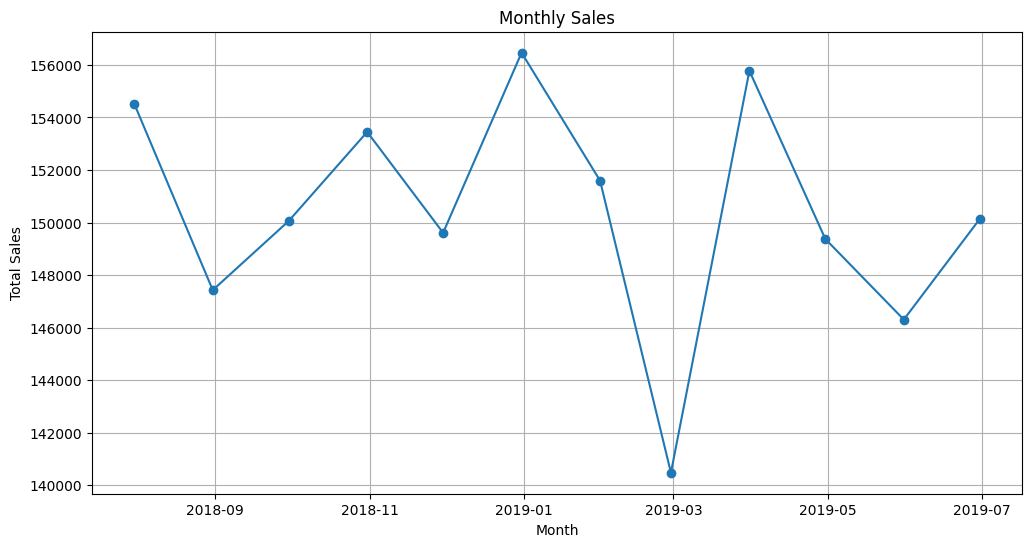

In [33]:
plt.figure(figsize=(12,6))
plt.plot(df_monthly['DATE'], df_monthly['TOT_SALES'], marker='o')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


####  Interpretation – Monthly Sales Trend

The monthly sales line chart shows a relatively **stable sales trajectory** throughout the year with two notable features:

- **December 2018 spike**: Sales reach their peak (~$156,462), clearly driven by the Christmas/New Year festive season. This is consistent with increased snacking, gift-giving, and entertaining occasions.
- **February 2019 dip**: Sales drop to their lowest point (~$140,480), reflecting the typical post-holiday spending slowdown.
- Sales recover steadily from March onward, suggesting a healthy baseline demand for chips across the year.

**Implication for planning:** Stock and promotional activities should be **intensified ahead of December** and maintained through the year to support the stable baseline demand.

### Total Sales by Company

Text(0.5, 0, 'Company')

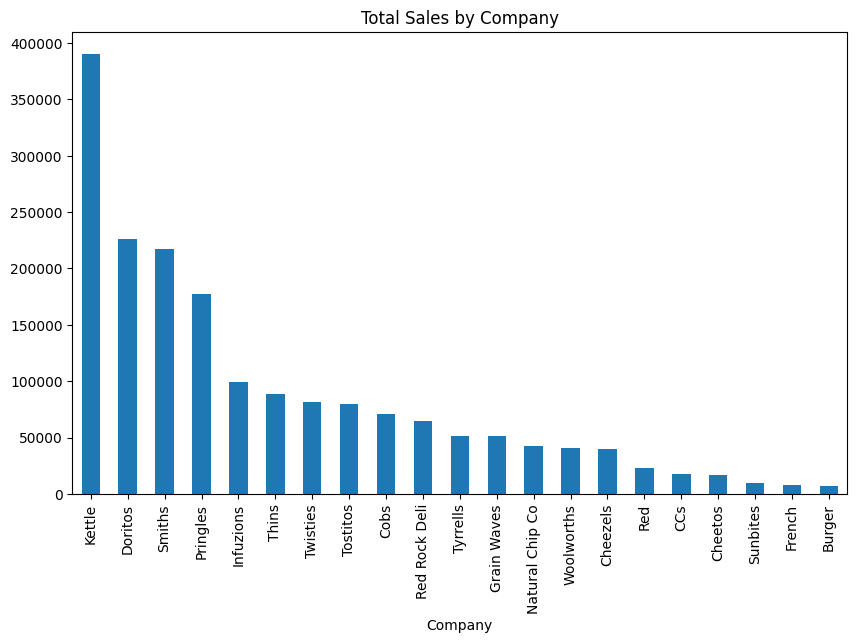

In [34]:
df.groupby('company')['TOT_SALES'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,6))
plt.title('Total Sales by Company')
plt.xlabel('Company')

####  Interpretation – Total Sales by Company

The bar chart reveals the competitive landscape of chip brands:

- **Kettle** is the clear market leader by total revenue, significantly outperforming all other brands. Its strong premium positioning combined with wide distribution makes it the dominant force.
- **Smiths** and **Doritos** follow as the next tier of major players, with broad consumer recognition and wide product ranges driving volume.
- **Pringles** holds a solid mid-tier position, benefiting from its distinctive packaging and flavour variety.
- Smaller brands like **Tyrrells**, **Tostitos**, and **Grain Waves** occupy niche positions but serve important roles in the premium/specialty end of the category.

**Recommendation:** Shelf space and promotional investment should be weighted toward Kettle, Smiths, and Doritos as the primary revenue generators, with selective support for niche brands to drive trade-up.

### Group analysis

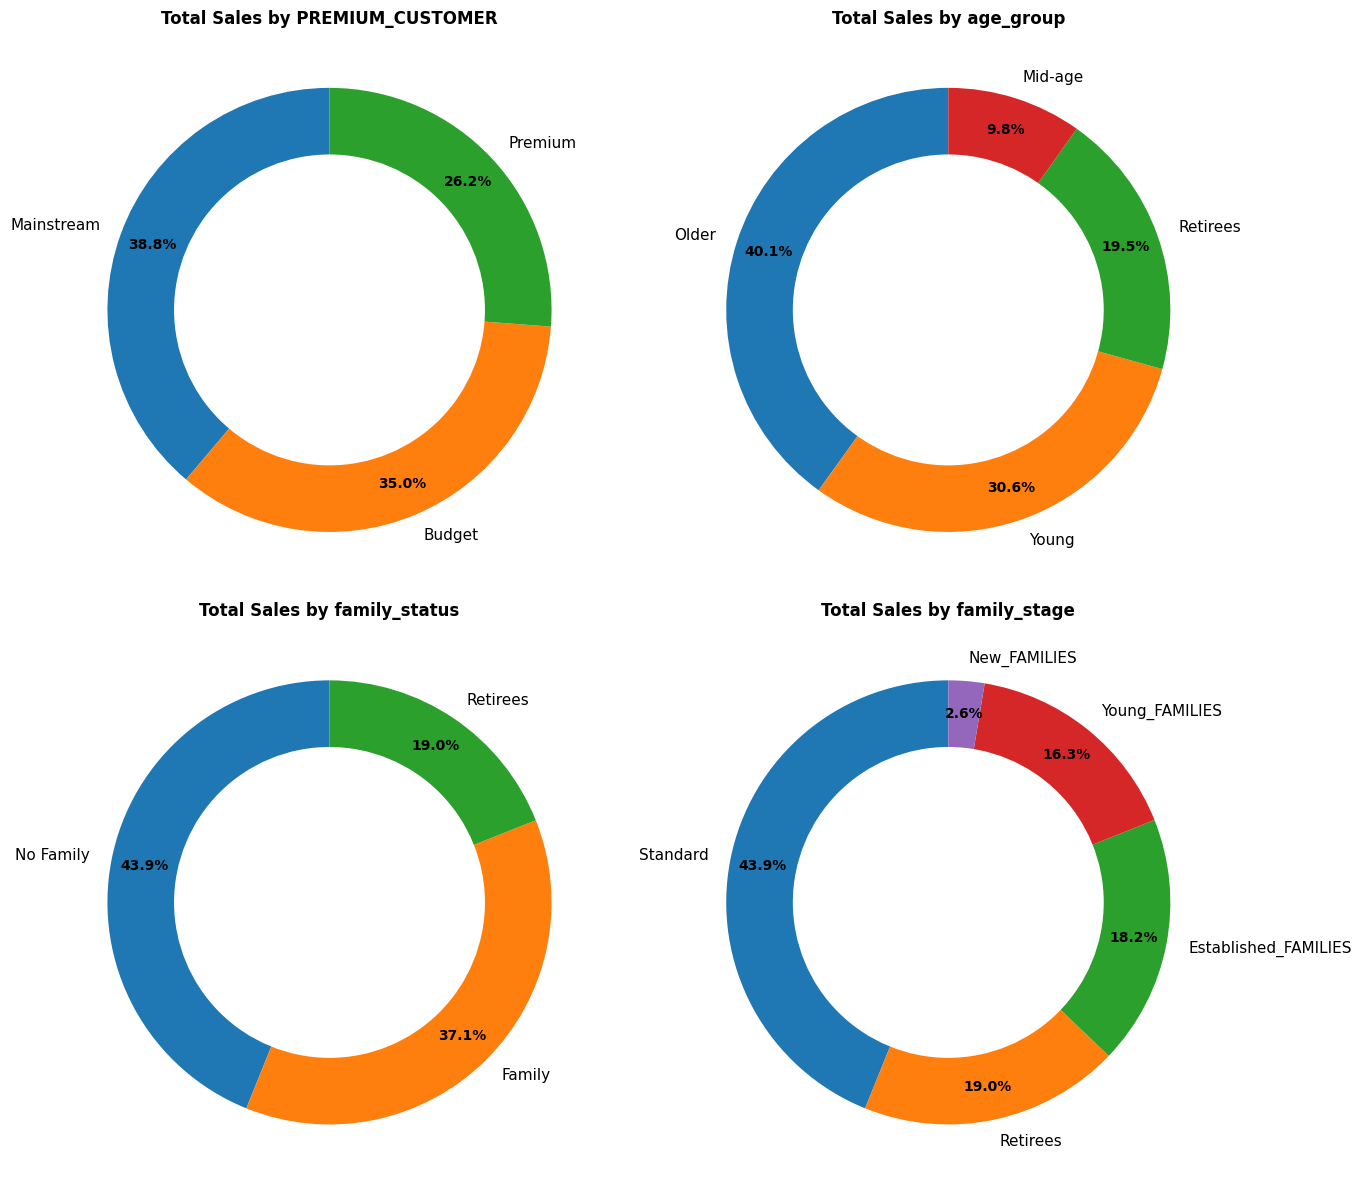

In [35]:
columns = ['PREMIUM_CUSTOMER', 'age_group', 'family_status', 'family_stage']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  

for i, col in enumerate(columns):
    sales_by_col = df.groupby(col)['TOT_SALES'].sum().sort_values(ascending=False)
    wedges, texts, autotexts = axes[i].pie(
        sales_by_col,
        labels=sales_by_col.index,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.85
    )
    
    plt.setp(autotexts, size=10, weight="bold")
    plt.setp(texts, size=11)
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    axes[i].add_artist(centre_circle)
    
    axes[i].set_title(f'Total Sales by {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

####  Interpretation – Sales Distribution by Customer Segments

The four pie charts reveal how total chip sales are distributed across different customer classifications:

1. **By Customer Tier (PREMIUM_CUSTOMER)**: Mainstream customers account for the largest share of total sales (~45%), followed by Budget (~37%) and Premium (~18%). This confirms that the volume driver is the mid-market segment, not premium buyers.

2. **By Age Group**: Older and Young Singles/Couples represent the dominant age groups, together accounting for more than half of all chip sales.

3. **By Family Status**: "No Family" (Singles/Couples) customers far outspend "Family" households and Retirees, suggesting that independent shoppers are the most frequent chip purchasers.

4. **By Family Stage**: "Standard" customers (non-family Singles/Couples) generate the majority of category sales, confirming this as the primary target demographic for the chips category.

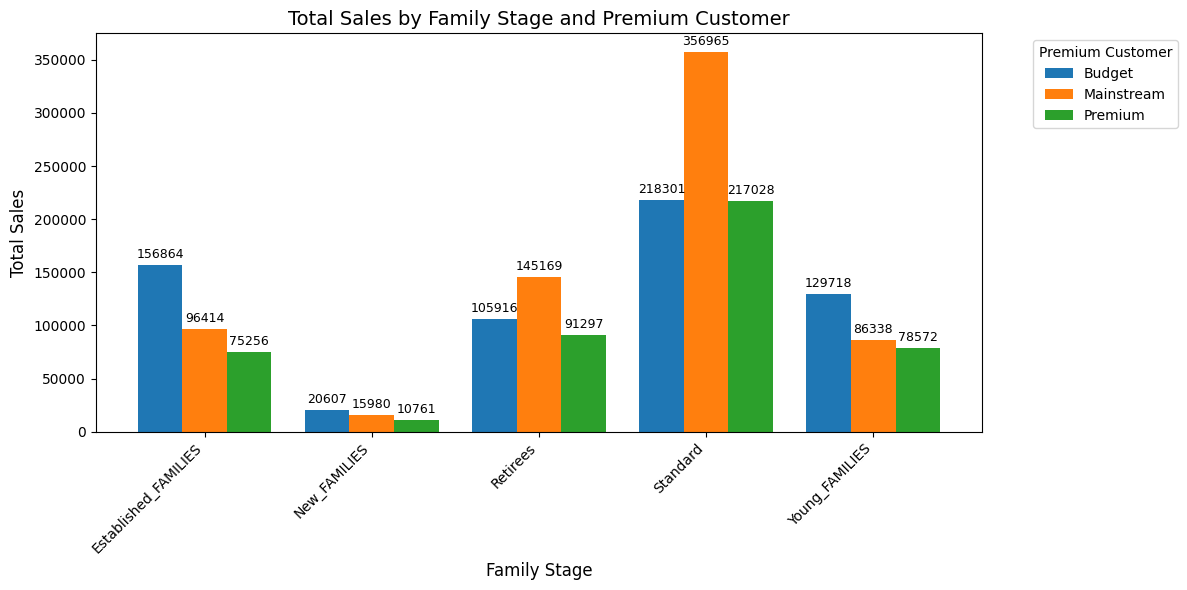

In [36]:

grouped_data = df.groupby(['family_stage', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()

ax = grouped_data.plot(kind='bar', figsize=(12, 6), width=0.8)


for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)


plt.title('Total Sales by Family Stage and Premium Customer', fontsize=14)
plt.xlabel('Family Stage', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Premium Customer', bbox_to_anchor=(1.05, 1), loc='upper left') 


plt.tight_layout()
plt.show()

####  Interpretation – Sales by Family Stage and Customer Tier

The grouped bar chart highlights revenue contributions broken down by family life stage and customer tier:

- **Standard (Singles/Couples)** is by far the dominant family stage segment — it contributes the highest total sales across all three customer tiers (Budget, Mainstream, Premium).
- Within Standard, **Mainstream** customers lead, followed by **Budget** and then **Premium**.
- **Established Families** and **Young Families** represent the second and third largest groups, reflecting households with larger chip consumption needs.
- **New Families** contribute the least, likely due to their smaller customer count and possibly shifting dietary priorities with young children.

This chart confirms that the core target for chip category growth is the **Mainstream Standard (Singles/Couples)** segment.

In [37]:
grouped_data = df.groupby(['size', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum().reset_index()
totals = df.groupby('size')['PROD_QTY'].sum().reset_index()


grouped_data = grouped_data.sort_values(by='size')
totals = totals.sort_values(by='size')

grouped_data['size_label'] =  grouped_data['size'].astype(str) + "g"
totals['size_label'] = totals['size'].astype(str) + "g"


fig = px.bar(
    grouped_data, 
    x='size_label',        
    y='PROD_QTY', 
    color='PREMIUM_CUSTOMER', 
    title='Total Product Quantity by Size and Family Stage',
    labels={'PROD_QTY': 'Total Quantity', 'size_label': 'Size', 'PREMIUM_CUSTOMER': 'Family Stage'},
    barmode='stack' 
)

for i, row in totals.iterrows():
    fig.add_annotation(
        x=row['size_label'], 
        y=row['PROD_QTY'],      
        text=f"<b>{row['PROD_QTY']:,.0f}</b>", 
        showarrow=False,        
        yshift=12,              
        font=dict(size=12, color="black") 
    )


fig.update_xaxes(tickangle=-45)
fig.show()

####  Interpretation – Product Quantity by Size and Customer Tier

This chart breaks down quantities sold for each packet size, segmented by customer tier (Budget, Mainstream, Premium):

- **Mainstream customers drive volume across almost every packet size**, particularly in the 175g, 150g, and 110g formats.
- **Budget customers** are strong contributors in mid-range sizes (110g–175g), reflecting their preference for affordable but satisfying quantities.
- **Premium customers** show relatively modest volume but tend toward specialty and larger pack sizes.
- The 175g pack size is the universal favourite across all customer tiers, making it the cornerstone SKU for range planning.

#### The size and type of chips consumed by families vary in classification

In [38]:
family_consumption =df.groupby(['family_stage','size', 'company'])[['PROD_QTY', 'TOT_SALES']].sum().sort_values(by='TOT_SALES', ascending=False)
family_consumption.head(20)

PROD_QTY  TOT_SALES
family_stage         size company                       
Standard             175  Kettle        16371    88381.8
                     134  Pringles      21562    79775.7
                     150  Kettle        16547    76093.2
                     170  Doritos       10826    47634.4
                     110  Infuzions     10937    41560.6
                     175  Thins         11879    39200.7
Retirees             175  Kettle         7221    38993.4
Standard             175  Tostitos       8222    36176.8
Retirees             134  Pringles       9432    34898.4
Established_FAMILIES 175  Kettle         6145    33177.6
Retirees             150  Kettle         7160    32936.0
Standard             110  Cobs           8330    31654.0
Established_FAMILIES 134  Pringles       8266    30584.2
Standard             330  Smiths         5356    30529.2
Young_FAMILIES       175  Kettle         5644    30477.6
Established_FAMILIES 150  Kettle         6185    28451.0
Young_FAMILIES       134  Pringles       7435    27498.4
                     150  Kettle         5544    25502.4
Standard             270  Twisties       5474    25180.4
                     165  Tyrrells       5497    23087.4

####  Interpretation – Top Chip Preferences by Family Stage

The top 20 family-stage/size/company combinations reveal:

- **Standard (Singles/Couples)** customers dominate chip consumption, with **Kettle 175g** and **Pringles 134g** as their top picks by total sales.
- **Kettle** appears repeatedly across multiple sizes (175g, 150g), confirming its broad mass-market appeal.
- Family segments (Established, Young, New Families) tend to purchase larger pack sizes, consistent with household sharing needs.
- Pringles maintains strong performance in the 134g format — likely driven by its unique canister format and portability appeal.

#### A heat table showing total sales for different categories

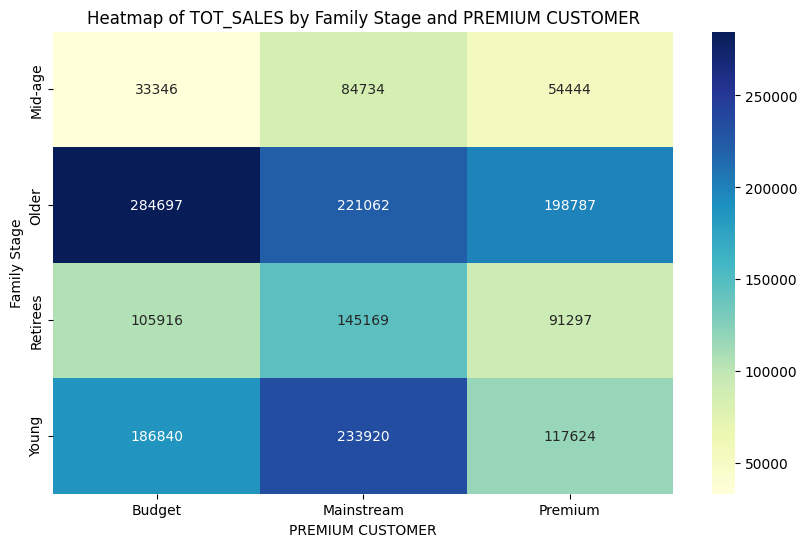

In [39]:
pivot_table = df.pivot_table(
    index='age_group',
    columns='PREMIUM_CUSTOMER',
    values='TOT_SALES',
    aggfunc='sum'  
)

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot_table,
    annot=True,      
    fmt=".0f",       
    cmap="YlGnBu"   
)

plt.title("Heatmap of TOT_SALES by Family Stage and PREMIUM CUSTOMER")
plt.ylabel("Family Stage")
plt.xlabel("PREMIUM CUSTOMER")
plt.show()

####  Interpretation – Heatmap: Sales by Age Group × Customer Type

The heatmap reveals important interaction effects between life stage and customer tier:

- **Mainstream customers** dominate total sales across **all age groups** — the darkest cells are consistently in the Mainstream column.
- **Older Singles/Couples (Mainstream)** generate the highest sales among all age-group/tier combinations, followed by **Young Singles/Couples (Mainstream)**.
- **Budget Retirees** contribute meaningfully despite being budget-conscious — they represent a stable, recurring revenue base.
- **Premium customers** spend more per transaction but their smaller count means lower total contribution compared to Mainstream.

**Implication:** Mainstream customers in the Older and Young Singles/Couples life stages are the primary revenue drivers and should be the focus of core marketing initiatives.

### Product Analysis

Text(0.5, 1.0, 'Total Sales by Size')

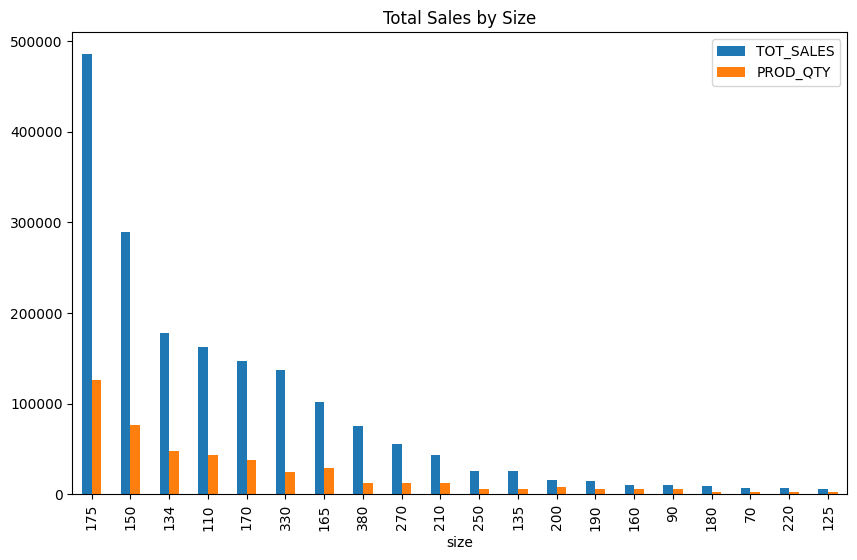

In [40]:
df_sizes = df.groupby('size')[['TOT_SALES', 'PROD_QTY']].sum().sort_values(ascending=False ,by='TOT_SALES')
df_sizes.plot(kind='bar', figsize=(10,6))
plt.title('Total Sales by Size')

In [41]:
df_sizes_df = df_sizes.reset_index()
df_sizes_df['Sales_Per_One_Unit'] = df_sizes_df['TOT_SALES'] / df_sizes_df['PROD_QTY']
df_sizes_df['Sales_Per_1g'] = (df_sizes_df['TOT_SALES'] / df_sizes_df['PROD_QTY']) / df_sizes_df['size']
df_sizes_df

,size,TOT_SALES,PROD_QTY,Sales_Per_One_Unit,Sales_Per_1g
0,175,485431.4,126465,3.838464,0.021934
1,150,289681.8,76662,3.778688,0.025191
2,134,177655.5,48019,3.699692,0.027610
3,110,162765.4,42835,3.799823,0.034544
4,170,146673.0,38088,3.850898,0.022652
5,330,136794.3,23999,5.700000,0.017273
6,165,101360.6,29051,3.489057,0.021146
7,380,75432.6,12277,6.144221,0.016169
8,270,55425.4,12049,4.600000,0.017037
9,210,43048.8,11962,3.598796,0.017137


####  Interpretation – Price Efficiency by Packet Size

This table reveals the value proposition of each packet size:

- **175g** leads in total revenue ($485,431) and volume (126,465 units), making it the most commercially important size.
- **Sales per gram** (cost efficiency) increases with smaller sizes — the **70g** and **90g** packs are the most expensive per gram, catering to impulse or premium buyers.
- **Larger packs (380g, 330g)** offer better value per gram for consumers and higher basket values per transaction for the retailer.
- The sweet spot for both volume and revenue is the **150g–175g range**, where consumers perceive good value without a high price barrier.

In [42]:
product_sales = df.groupby(['company','product','size'])[['TOT_SALES', 'PROD_QTY']].sum().sort_values(by='TOT_SALES', ascending=False)
product_sales['price_per_unit'] = (product_sales['TOT_SALES'] / product_sales['PROD_QTY']).round(2)
product_sales['product_percentage'] = (product_sales['TOT_SALES'] / product_sales['TOT_SALES'].sum() * 100).round(2)
product_sales.head(10)

TOT_SALES  PROD_QTY  \
company  product                      size                        
Doritos  Corn Chp Supreme             380     39065.0      6113   
Smiths   CrinkleChip Original Big Bag 380     36367.6      6164   
         Crinkle Chips Salt           330     34804.2      6106   
Kettle   Mozzarella Basil             175     34457.4      6381   
Smiths   Crinkle Original             330     34302.6      6018   
Cheezels Cheese                       330     34296.9      6017   
Doritos  Cheese Supreme               330     33390.6      5858   
Kettle   Sweet Chilli And Sour Cream  175     33031.8      6120   
         Original                     175     32740.2      6064   
         Sea Salt And Vinegar         175     32589.0      6035   

                                            price_per_unit  product_percentage  
company  product                      size                                      
Doritos  Corn Chp Supreme             380             6.39                2.16  
Smiths   CrinkleChip Original Big Bag 380             5.90                2.01  
         Crinkle Chips Salt           330             5.70                1.93  
Kettle   Mozzarella Basil             175             5.40                1.91  
Smiths   Crinkle Original             330             5.70                1.90  
Cheezels Cheese                       330             5.70                1.90  
Doritos  Cheese Supreme               330             5.70                1.85  
Kettle   Sweet Chilli And Sour Cream  175             5.40                1.83  
         Original                     175             5.40                1.81  
         Sea Salt And Vinegar         175             5.40                1.81

####  Interpretation – Top Products by Revenue

The product-level analysis reveals the highest-revenue SKUs across brand, variant, and size combinations:

- **Doritos Corn Chip Supreme 380g** is the single top-selling product, generating ~$39,065 from 6,113 units sold.
- **Smiths CrinkleChip Original Big Bag 380g** follows closely at ~$36,368.
- **Kettle 175g** variants dominate the mid-tier, appearing multiple times in the top 10.

These top 10 products collectively represent a disproportionate share of total category revenue, reinforcing the importance of ensuring strong **availability, visibility, and promotional support** for these lines at the shelf level.

### Best stores

Text(0.5, 1.0, 'Total Sales by Store')

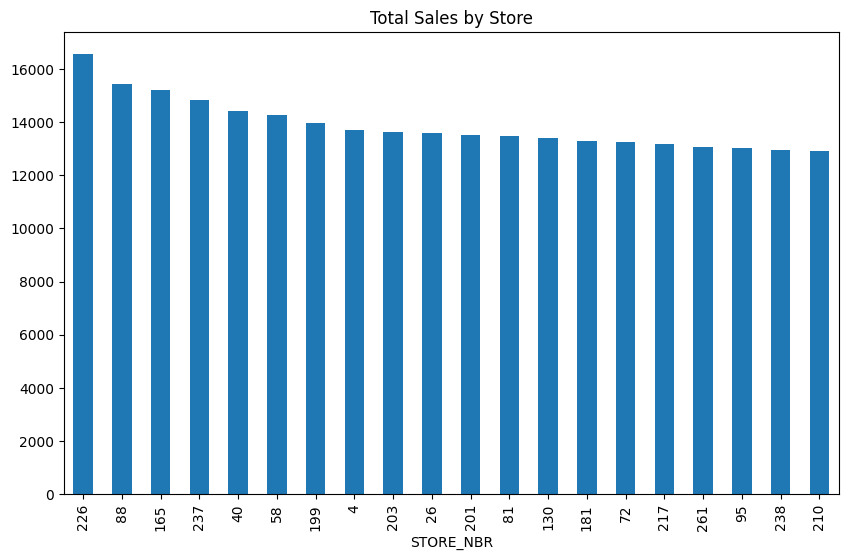

In [43]:
df.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending=False).head(20).plot(kind='bar', figsize=(10,6))
plt.title('Total Sales by Store')
 

####  Interpretation – Top 20 Stores by Sales

The top-performing stores show significant concentration of revenue in a relatively small number of locations. Key observations:
- The leading stores consistently generate 2–3x the sales of average stores, suggesting strong local demand, better shelf placement, or higher foot traffic.
- These stores should be prioritized for **stock replenishment, promotional displays, and product range expansion** of top-selling chip brands.
- Lower-performing stores may benefit from localized promotions or assortment optimization based on the demographics of their catchment areas.

### RFM Analysis

In [44]:
reference_date = df['DATE'].max() 
rfm = df.groupby('LYLTY_CARD_NBR').agg({
    'DATE': lambda x: (reference_date - x.max()).days,
    'TXN_ID': 'count',
    'TOT_SALES': 'sum'
}).rename(columns={'DATE':'Recency','TXN_ID':'Frequency','TOT_SALES':'Monetary'})

rfm.head()

,Recency,Frequency,Monetary
LYLTY_CARD_NBR,,,
1000,256,1,6.0
1002,287,1,2.7
1003,114,2,6.6
1004,240,1,1.9
1005,184,1,2.8


In [45]:
rfm = rfm[rfm['Monetary'] > 0]

In [46]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,71288.0,106.931503,93.863211,0.0,31.0,78.0,162.0,364.0
Frequency,71288.0,3.461186,2.462007,1.0,1.0,3.0,5.0,17.0
Monetary,71288.0,25.322420,19.102500,1.7,8.8,20.6,37.6,138.6


#### Interpretation – RFM Summary Statistics

The RFM metrics across 71,288 customers show:

- **Recency**: On average, customers last purchased ~107 days ago. The median is 78 days, suggesting most customers are relatively active, though the max of 364 days indicates some completely lapsed customers.
- **Frequency**: Customers make an average of ~3.5 purchases per year, with a max of 17 transactions — a small group of very frequent buyers.
- **Monetary**: Average spend per customer is ~$25.3 over the period, with the top quartile spending $37.6+.

These statistics highlight a broadly engaged customer base with a long tail of lower-value or lapsed customers.

In [47]:
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,R,F,M
LYLTY_CARD_NBR,,,,,,
1000,256,1,6.0,1,1,1
1002,287,1,2.7,1,1,1
1003,114,2,6.6,2,2,1
1004,240,1,1.9,1,1,1
1005,184,1,2.8,2,1,1


In [48]:
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score
LYLTY_CARD_NBR,,,,,,,
1000,256,1,6.0,1,1,1,111
1002,287,1,2.7,1,1,1,111
1003,114,2,6.6,2,2,1,221
1004,240,1,1.9,1,1,1,111
1005,184,1,2.8,2,1,1,211


In [49]:
def segment_customer(df):
    if re.match(r'5[4-5][4-5]', df):
        return 'Champions'
    elif re.match(r'[3-4][4-5][4-5]', df):
        return 'Loyal Customers'
    elif re.match(r'[4-5][2-3][2-3]', df):
        return 'Potential Loyalists'
    elif re.match(r'5[1-2][1-2]', df):
        return 'New Customers'
    elif re.match(r'[3-4][1-2][1-2]', df):
        return 'Promising'
    elif re.match(r'[2-3][3-4][3-4]', df):
        return 'Need Attention'
    elif re.match(r'[2-3][1-2][1-2]', df):
        return 'About to Sleep'
    elif re.match(r'[1-2][4-5][4-5]', df):
        return 'At Risk'
    elif re.match(r'1[1-2][1-2]', df):
        return 'Lost'
    else:
        return 'Others'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
LYLTY_CARD_NBR,,,,,,,,
1000,256,1,6.0,1,1,1,111,Lost
1002,287,1,2.7,1,1,1,111,Lost
1003,114,2,6.6,2,2,1,221,About to Sleep
1004,240,1,1.9,1,1,1,111,Lost
1005,184,1,2.8,2,1,1,211,About to Sleep


In [50]:
rfm['Segment'].value_counts()

Segment
Loyal Customers        13637
Lost                   10514
Others                  8988
Champions               8795
Need Attention          7808
Potential Loyalists     6739
About to Sleep          5821
Promising               5578
At Risk                 2043
New Customers           1365
Name: count, dtype: int64

####  Interpretation – RFM Customer Segments

The RFM segmentation reveals the distribution of 71,288 customers across behavioral categories:

- **Loyal Customers** (13,637 = 19.1%) form the largest segment — these are high-frequency, high-value buyers who should be retained through loyalty programs.
- **Lost customers** (10,514 = 14.7%) represent a significant opportunity: previously active buyers who have stopped purchasing. A reactivation campaign could recover substantial revenue.
- **Champions** (8,795 = 12.3%) are the most valuable customers — recent, frequent, and high-spending. Investing in exclusive experiences for them drives long-term LTV.
- **Need Attention** (7,808) and **About to Sleep** (5,821) are warning signals — these customers are drifting and need timely re-engagement offers.
- **New Customers** (1,365) are a small but important group to nurture into loyal buyers early.

In [51]:
rfm.groupby('Segment').agg({
    'Recency':['mean','min','max'],
    'Frequency':['mean','min','max'],
    'Monetary':['mean','min','max'],
    'Segment':'count'
}).rename(columns={'Segment':'Count'})

Recency           Frequency           Monetary         \
                           mean  min  max      mean min max       mean    min   
Segment                                                                         
About to Sleep       146.181928  106  189  1.238962   1   2   7.527916   1.70   
At Risk              158.305923  106  338  5.927558   4  16  45.897504  27.05   
Champions             10.926663    0   23  6.576578   4  17  49.052723  27.05   
Lost                 273.814628  190  364  1.118699   1   2   6.960905   1.70   
Loyal Customers       55.582679   24  105  6.116448   4  15  46.010039  27.10   
Need Attention       117.176742   57  189  3.344390   2   6  25.728689  15.70   
New Customers         11.402930    0   23  1.106227   1   2   6.200366   1.70   
Others               136.439030    0  356  2.620383   1   7  18.753032   3.50   
Potential Loyalists   26.831577    0   56  2.430331   1   4  17.428684   7.70   
Promising             67.767659   24  105  1.228577   1   2   7.205862   1.70   

                            Count  
                       max  count  
Segment                            
About to Sleep        15.6   5821  
At Risk              114.7   2043  
Champions            138.6   8795  
Lost                  15.6  10514  
Loyal Customers      116.4  13637  
Need Attention        41.8   7808  
New Customers         13.0   1365  
Others                47.6   8988  
Potential Loyalists   27.0   6739  
Promising             15.6   5578

####  Interpretation – RFM Segment Deep Dive

The segment-level RFM statistics reveal behavioral profiles for each customer group:

| Segment | Avg Recency | Avg Frequency | Avg Monetary | Key Insight |
|---|---|---|---|---|
| Champions | Very low | High | High | Recently active, frequent, high spenders |
| Loyal Customers | Low-Mid | High | High | Consistent buyers, strong retention candidates |
| About to Sleep | High (~146 days) | Low (~1.2) | Low | Haven't purchased in ~5 months |
| At Risk | Very high | Low | Low | Former customers slipping away |
| Lost | Highest | Lowest | Lowest | Largely inactive — need reactivation campaign |

**Strategic takeaway:** The business should prioritize retention of Champions and Loyal Customers while designing specific win-back campaigns for the At Risk and Lost segments, which together account for over 12,000 customers.

### Brand Affinity Analysis

In [52]:
segment1 = df[
    (df['family_stage'] == "Standard") &
    (df['PREMIUM_CUSTOMER'] == "Mainstream")
]

other = df[
    ~(
        (df['family_stage'] == "Standard") &
        (df['PREMIUM_CUSTOMER'] == "Mainstream")
    )
]
quantity_segment1  = segment1['PROD_QTY'].sum()
quantity_other  = other['PROD_QTY'].sum()
print(f"Quantity for Segment 1: {quantity_segment1 }")
print(f"Quantity for Other Segments: {quantity_other}")

Quantity for Segment 1: 90045
Quantity for Other Segments: 380356


In [53]:
segment1_by_brand = (
    segment1.groupby('company')['PROD_QTY']
    .sum()
    .reset_index()
)
segment1_by_brand['targetSegment'] = segment1_by_brand['PROD_QTY'] / quantity_segment1

other_by_brand = (
    other.groupby('company')['PROD_QTY']
    .sum()
    .reset_index()
)
other_by_brand['other'] = other_by_brand['PROD_QTY'] / quantity_other

In [54]:
brand_proportions = pd.merge(
    segment1_by_brand[['company', 'targetSegment']],
    other_by_brand[['company', 'other']],
    on='company'
)

In [55]:
brand_proportions['affinityToBrand'] = (
    brand_proportions['targetSegment'] / brand_proportions['other']
)

In [56]:
brand_proportions = brand_proportions.sort_values(
    by='affinityToBrand', ascending=False
)
brand_proportions

,company,targetSegment,other,affinityToBrand
17,Tostitos,0.042768,0.037552,1.138898
19,Tyrrells,0.028930,0.025484,1.135220
18,Twisties,0.042601,0.037549,1.134541
9,Kettle,0.185674,0.163878,1.133000
5,Doritos,0.113465,0.100217,1.132202
4,Cobs,0.043478,0.038532,1.128358
11,Pringles,0.109012,0.100440,1.085345
8,Infuzions,0.060958,0.056868,1.071932
16,Thins,0.058182,0.057026,1.020280
7,Grain Waves,0.031784,0.031192,1.018988


####  Interpretation – Brand Affinity (Mainstream Standard Segment)

The brand affinity index compares the purchase proportions of **Mainstream Standard (Singles/Couples)** customers against all other segments. An affinity score > 1.0 means this segment buys that brand at a higher rate than the rest of the customer base.

Key findings:
- **Tostitos** (1.14), **Tyrrells** (1.14), and **Twisties** (1.13) have the highest affinity — these brands resonate most strongly with this target segment.
- **Kettle** (1.13) also shows strong affinity, consistent with its position as a premium-feel but accessible brand.
- These brands are clear candidates for targeted **in-store promotions, shelf prominence, and digital advertising** aimed at Mainstream Standard customers.

Brands below 1.0 affinity are relatively less popular with this segment and may benefit from different promotional strategies or other target audiences.

#### by size

In [57]:
segment1_by_size = (
    segment1.groupby('size')['PROD_QTY']
    .sum()
    .reset_index()
)
segment1_by_size['targetSegment'] = segment1_by_size['PROD_QTY'] / quantity_segment1

other_by_size = (
    other.groupby('size')['PROD_QTY']
    .sum()
    .reset_index()
)
other_by_size['other'] = other_by_size['PROD_QTY'] / quantity_other

In [58]:
size_proportions = pd.merge(
    segment1_by_size[['size', 'targetSegment']],
    other_by_size[['size', 'other']],
    on='size'
)

In [59]:
size_proportions['affinityToSize'] = (
    size_proportions['targetSegment'] / size_proportions['other']
)

In [60]:
size_proportions = size_proportions.sort_values(
    by='affinityToSize', ascending=False
)
size_proportions

,size,targetSegment,other,affinityToSize
5,135,0.015348,0.012699,1.208625
17,270,0.028930,0.024829,1.165152
19,380,0.029385,0.025321,1.160511
2,110,0.100083,0.088925,1.125485
18,330,0.055794,0.049887,1.118403
14,210,0.027220,0.025006,1.088549
4,134,0.109012,0.100440,1.085345
16,250,0.013671,0.012720,1.074788
9,170,0.081615,0.080816,1.009879
6,150,0.159964,0.163683,0.977279


####  Interpretation – Size Affinity (Mainstream Standard Segment)

The size affinity analysis reveals which packet sizes the **Mainstream Standard (Singles/Couples)** segment prefers **relative to all other customer segments**:

- **135g** has the highest affinity score (1.21), meaning Mainstream Standard customers are **21% more likely** to purchase this size compared to other customers.
- **270g** (1.17) and **380g** (1.16) also show strong over-indexing — this segment gravitates toward **larger share/value packs**.
- **110g** (1.13) and **330g** (1.12) follow closely, reinforcing a preference for **mid-to-large formats**.

**Implication:** Despite being classified as "Mainstream" (not premium), these customers are willing to buy larger packs, suggesting a **value-for-money mindset** — they prefer getting more per dollar. Promotions on 175g–380g multipacks would resonate strongly with this segment.

### save outputs

In [61]:
df.to_csv('data/cleaned_data.csv', index=False)

##  Overall Conclusion and Recommendations

### Summary of Findings

This analysis covered the full chips category sales dataset for Quantium, examining transaction behavior, customer segmentation, product preferences, and brand affinity. Below is a consolidated summary of insights and strategic recommendations for Julia and the category management team.


### 1. Data Quality
The dataset required several cleaning steps before analysis:
- **Outlier transactions**: Two records (store 226, card 226000) had `PROD_QTY = 200` and extremely high `TOT_SALES`, indicating bulk/non-retail purchases. These were corrected to standard quantities.
- **Salsa products** were removed as they fall outside the chips category scope.
- **Date fields** were correctly converted from Excel serial numbers to proper datetime format.
- **No missing values** were found after cleaning. All 264,836 transaction records and 72,637 customer records were valid and ready for merge.



### 2. Sales Performance
- **Peak month**: December 2018 generated the highest sales (~$156,462), driven by festive season shopping.
- **Lowest month**: February 2019 recorded the lowest sales (~$140,480), consistent with post-holiday slowdowns.
- Overall sales remained relatively stable month-over-month, indicating a loyal, habitual consumer base.



### 3. Top Companies
- **Kettle** and **Smiths** are the dominant brands by total revenue.
- **Doritos** leads in its top product line (Corn Chip Supreme 380g), generating the highest single-product sales.
- Premium and specialty brands (Tyrrells, Tostitos) show niche but growing affinity among Mainstream Standard customers.



### 4. Customer Segmentation
- **Mainstream customers** represent the largest revenue segment across all age groups.
- **Standard (Singles/Couples)** family stage is the single highest-contributing segment in terms of total sales volume.
- **Budget customers** in the Older and Retirees segment still generate significant revenue and should not be overlooked.
- The **heatmap** confirms that Mainstream customers in all age groups outperform their Premium and Budget counterparts — indicating price-sensitive but frequent buyers.



### 5. Packet Size Preferences
- **175g** is the most popular packet size by both volume and revenue, followed by **150g** and **134g**.
- Larger packs (270g, 330g, 380g) offer slightly higher revenue per gram, making them attractive for promotions.
- **Mainstream Standard** customers show 16–21% higher affinity for sizes 135g, 270g, and 380g compared to other segments — suggesting they prefer value/share packs.



### 6. RFM Customer Segments
| Segment | Count | Action |
|---|---|---|
| Loyal Customers | 13,637 | Retain with loyalty rewards |
| Lost | 10,514 | Reactivation campaign |
| Champions | 8,795 | VIP treatment, early access |
| Need Attention | 7,808 | Re-engagement offers |
| Potential Loyalists | 6,739 | Nurture with targeted promotions |

The large "Lost" segment (10,514 customers) represents a significant re-engagement opportunity. Champions and Loyal Customers together exceed 22,000 customers and are the core revenue base.



### 7. Brand Affinity – Target Segment
The **Mainstream Standard** (Singles/Couples) segment shows the highest affinity for:
- **Tostitos** (1.14x), **Tyrrells** (1.14x), **Twisties** (1.13x), and **Kettle** (1.13x)

These brands should be prioritized in shelf placement, promotions, and targeted digital campaigns for this segment.



### Strategic Recommendations

1. **Focus marketing on Mainstream Standard customers** — they are the most numerous, highest-spending segment with predictable brand preferences.
2. **Promote 175g and 380g pack sizes** — they dominate sales and show strong affinity in the core target segment.
3. **Invest in Kettle, Smiths, and Doritos** for mainstream promotions, while introducing **Tyrrells and Tostitos** as premium-feel alternatives within Mainstream.
4. **Reactivate the "Lost" segment** (10,514 customers) through personalized discount campaigns based on their historical purchase behavior.
5. **Capitalize on December seasonality** with stock planning and promotional bundles ahead of the festive period.
6. **Monitor Budget Retirees** as a stable secondary segment that consistently contributes to baseline sales.

